# Bouncing Ball Hybrid Automaton

This notebook demonstrates the running of a hybrid automaton implementation for `v0.0.4` of the hybrid-automaton pythonic API framework for hybrid automaton creation as well as some evaluation of how it runs.

## Structure Initialization

Initially we retrieve the already defined pythonic `amd (automaton model definition)` definition for the hybrid autoamton. When we print it's `__str__` function we see the AMDL represenation, and when we use `__repr__` we see the .mmd file represenation of the automaton which we can use for generatation of `https://mermaid.live/` state diagrams for visual analysis of the formalized automaton.

```mermaid
 stateDiagram-v2
    direction LR
    [*] --> FLYING
    FLYING --> GROUND: hit_ground
    GROUND --> FLYING: bounce_up
    GROUND --> GROUND: stop
```

In [ ]:
from hybrid_automatons import bouncing_ball
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunne
r
import asyncio
import numpy as np


ha: Automaton = bouncing_ball(gravity=-9.81, restitution=0.8)
print (ha)

Hybrid Automaton Definition:
	name: Bouncing Ball
	id: 1
	initial_mode: FLYING
	modes: [FLYING, GROUND]
	transitions:
		FLYING --[hit_ground]--> GROUND
		GROUND --[bounce_up]--> FLYING
		GROUND --[stop]--> GROUND
	guards:
		hit_ground: [hits_ground]
		bounce_up: [bounce_possible]
		stop: [no_more_bounce]
	resets:
		hit_ground: bounce_reset
		bounce_up: <none>
		stop: stop_reset
	invariants:
		FLYING: [no_more_bounce]
		GROUND: [no_more_bounce]
	continous_dynamics:
		FLYING -> flying_flow
		GROUND -> ground_flow



In [4]:
print (f"Hybrid Automaton `.mmd` diagram: \n", repr(ha))

Hybrid Automaton `.mmd` diagram: 
 stateDiagram-v2
    direction LR
    [*] --> FLYING
    FLYING --> GROUND: hit_ground
    GROUND --> FLYING: bounce_up
    GROUND --> GROUND: stop


In [ ]:
ha_runner: AutomatonRunner = AutomatonRunner(hybrid_automaton=ha, sampling_rate=0.001)
await ha_runner.run(
    x0=np.array([5.0, 0.0]), collect_auxiliary=False, collect_control=False, real_time_mode=False, integrate=True, duration=10.0, dt=0.001
)

activating automaton 'Bouncing Ball'...
automaton 'Bouncing Ball' evaluation loop worker starting.
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING
[EXIT] FLYING
[ENTER] GROUND
[EXIT] GROUND
[ENTER] FLYING


{'continuous_states': [[0.001, array([ 5.     , -0.00981])],
  [0.002, array([ 4.99999019, -0.01962   ])],
  [0.003, array([ 4.99997057, -0.02943   ])],
  [0.004, array([ 4.99994114, -0.03924   ])],
  [0.005, array([ 4.9999019, -0.04905  ])],
  [0.006, array([ 4.99985285, -0.05886   ])],
  [0.007, array([ 4.99979399, -0.06867   ])],
  [0.008, array([ 4.99972532, -0.07848   ])],
  [0.009000000000000001, array([ 4.99964684, -0.08829   ])],
  [0.010000000000000002, array([ 4.99955855, -0.0981    ])],
  [0.011000000000000003, array([ 4.99946045, -0.10791   ])],
  [0.012000000000000004, array([ 4.99935254, -0.11772   ])],
  [0.013000000000000005, array([ 4.99923482, -0.12753   ])],
  [0.014000000000000005, array([ 4.99910729, -0.13734   ])],
  [0.015000000000000006, array([ 4.99896995, -0.14715   ])],
  [0.016000000000000007, array([ 4.9988228, -0.15696  ])],
  [0.017000000000000008, array([ 4.99866584, -0.16677   ])],
  [0.01800000000000001, array([ 4.99849907, -0.17658   ])],
  [0.0190000

In [3]:
ha_runner.print_summary()
results = ha_runner.get_results()

Collected 8228 continuous state samples
Collected 0 auxiliary state samples
Collected 0 control input samples
Collected 8228 automaton state samples
Collected 8228 transition time samples


In [11]:
# print (results['continuous_states'])
# print (results['automaton_states'])
# print (results['automaton_states'])
# print (results['transition_times'])

/home/ryan/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


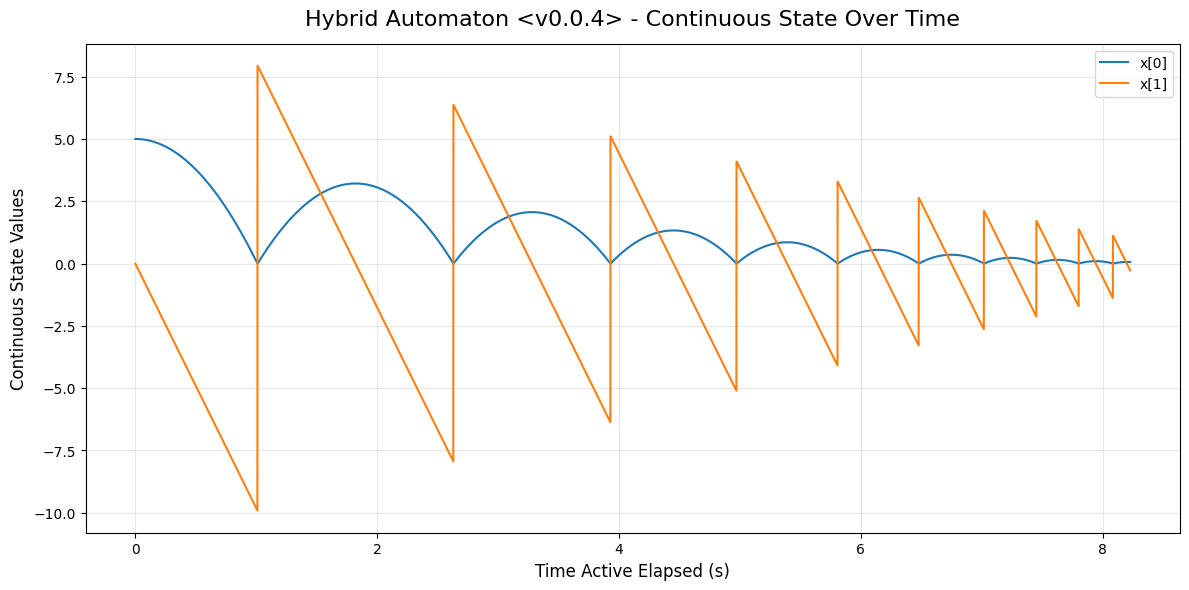

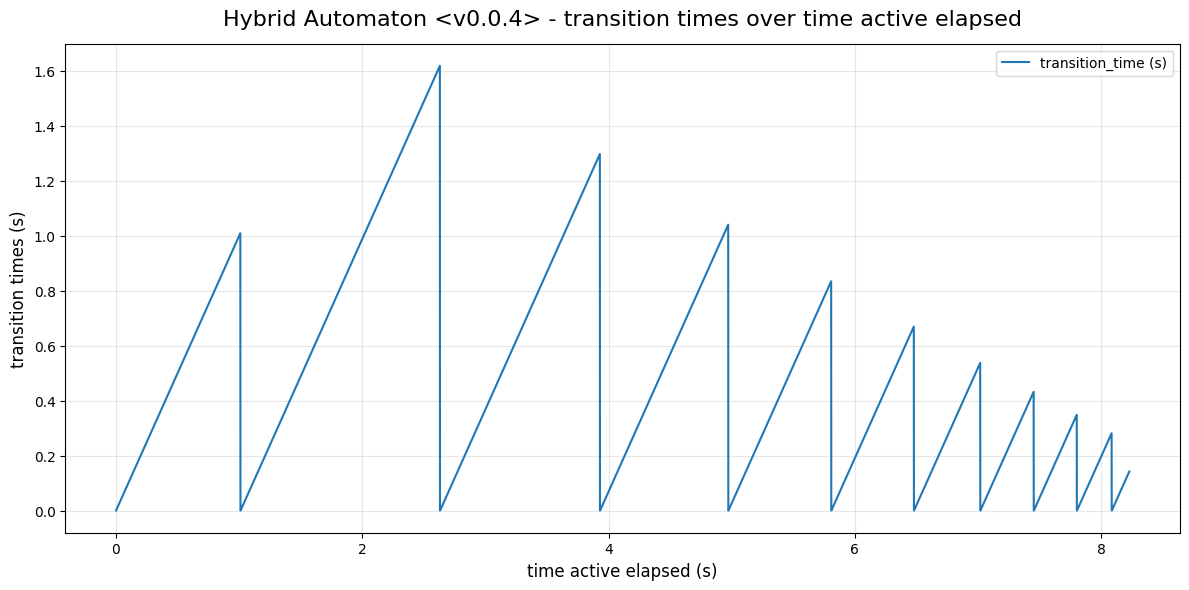

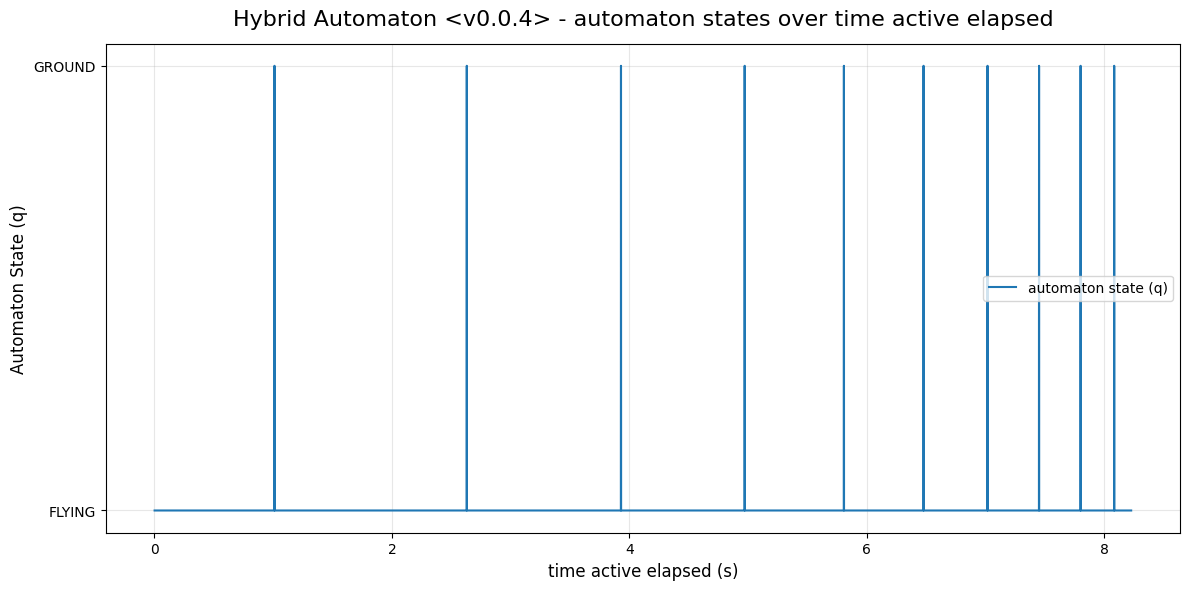

In [4]:
import matplotlib.pyplot as plt
from typing import List, Tuple
from hybrid_automaton_evaluation.figure_generator import continuous_states_over_time_fig, transitions_times_over_time_fig, automaton_states_over_time 

fig1 = continuous_states_over_time_fig(results['continuous_states'])
# fig2 = auxiliary_states_over_time_fig(results['auxiliary_states'])
# fig3 = control_inputs_over_time_fig(results['control_inputs'])
fig4 = transitions_times_over_time_fig(results['transition_times'])
fig5 = automaton_states_over_time(results['automaton_states'])
plt.show()